<a href="https://colab.research.google.com/github/Amuw9/cgitraining/blob/main/Assignment_OKR_READY_outcome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
print("Environment ready ✅")

Environment ready ✅


In [6]:
okrs = pd.DataFrame([
    {"objective":" Recover from database incidents automatically  with minimal customer impact",
    "key_result": "Reduce average recovery time from 45 minutes to 5 minutes",
    "baseline": 45,"current": 18,"target": 5,"unit": "minutes", "lower_is_better": True,
    "owner": "SRE squad",
    "quarter": "Q3"},
    {"objective":" Recover from database incidents automatically  with minimal customer impact",
    "key_result": "Reduce Sev-1 recovery time",
    "baseline": 60,"current": 30,"target": 10,"unit": "minutes", "lower_is_better": True,
    "owner": "SRE squad",
    "quarter": "Q3"},
     {"objective":" Incerease the reliability of databse",
    "key_result": "Increase concurrent connections",
    "baseline": 500,"current": 800,"target": 1500,"unit": "TPS", "lower_is_better": False,
    "owner": "DBA",
    "quarter": "Q3"},
    {"objective":" Availabilty of Database",
      "key_result": "Reduce dowuntime of database",
    "baseline": 5,"current": 4,"target": 1,"unit": "hours/month", "lower_is_better": True,
    "owner": "DBA",
    "quarter": "Q3"},
])

def progress_pct(row):
    span = row.target - row.baseline
    done = row.current - row.baseline
    pct = 0 if span == 0 else (done / span) * 100
    return round(max(0, min(100, pct)), 1)

okrs["progress_pct"] = okrs.apply(progress_pct, axis=1)
okrs

,objective,key_result,baseline,current,target,unit,lower_is_better,owner,quarter,progress_pct
0,Recover from database incidents automatically...,Reduce average recovery time from 30 minutes t...,45,18,5,minutes,True,SRE squad,Q3,67.5
1,Recover from database incidents automatically...,Reduce Sev-1 recovery time,60,30,10,minutes,True,SRE squad,Q3,60.0
2,Incerease the reliability of databse,Increase concurrent connections,500,800,1500,TPS,False,DBA,Q3,30.0
3,Availabilty of Database,Reduce dowuntime of database,5,4,1,hours/month,True,DBA,Q3,25.0


/tmp/ipykernel_1582/780160626.py:15: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1582/780160626.py:15: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1582/780160626.py:15: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print

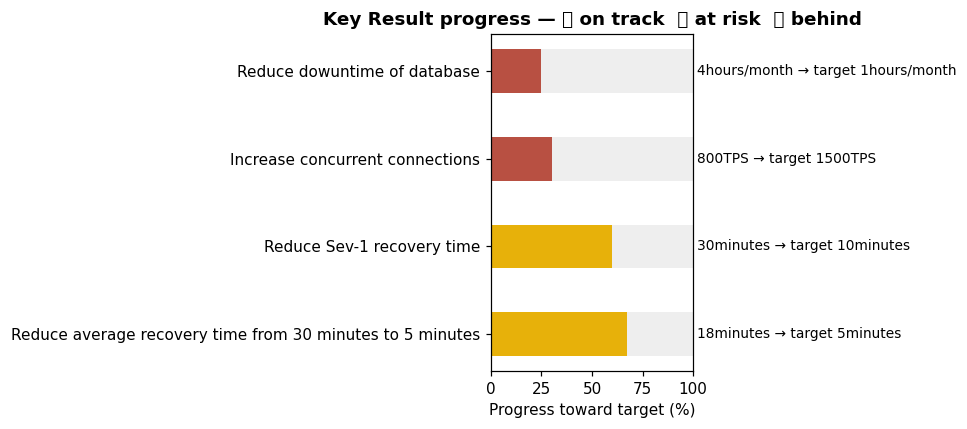

In [7]:
ig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(okrs))
colors = ["#2C5F2D" if p >= 70 else "#E7B10A" if p >= 40 else "#B85042" for p in okrs.progress_pct]

ax.barh(y_pos, okrs.progress_pct, color=colors, height=0.5)
ax.barh(y_pos, 100, color="#EEEEEE", height=0.5, zorder=0)
ax.barh(y_pos, okrs.progress_pct, color=colors, height=0.5, zorder=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(okrs.key_result)
ax.set_xlim(0, 100)
ax.set_xlabel("Progress toward target (%)")
ax.set_title("Key Result progress — 🟢 on track  🟡 at risk  🔴 behind", fontsize=12, fontweight="bold")
for i, (p, cur, tgt, unit) in enumerate(zip(okrs.progress_pct, okrs.current, okrs.target, okrs.unit)):
    ax.text(102, i, f"{cur}{unit} → target {tgt}{unit}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
roadmap = pd.DataFrame([
    {"initiative": "One-click checkout",        "key_result": "Cut checkout time from 90s to 30s",
     "start": "2026-07-01", "end": "2026-08-15", "confidence": "High"
     },
    { "initiative": "Automated database failover","key_result": "Increase database uptime from 99.90% to 99.999%",
      "start": "2026-07-01","end": "2026-08-15","confidence": "High"
      },
    { "initiative": "Real-time health monitoring","key_result": "Increase database uptime from 99.90% to 99.999%",
      "start": "2026-07-15","end": "2026-08-31","confidence": "High"
    },
    { "initiative": "Automated incident recovery","key_result": "Reduce average recovery time from 45 minutes to 5 minutes",
      "start": "2026-09-01","end": "2026-09-15","confidence": "High"
    },
    {"initiative": "Self-healing database clusters","key_result": "Reduce average recovery time from 45 minutes to 5 minutes",
      "start": "2026-09-15","end": "2026-10-15","confidence": "Medium"
    },
])
roadmap["start"] = pd.to_datetime(roadmap["start"])
roadmap["end"] = pd.to_datetime(roadmap["end"])
roadmap["duration_days"] = (roadmap["end"] - roadmap["start"]).dt.days
roadmap

,initiative,key_result,start,end,confidence,duration_days
0,One-click checkout,Cut checkout time from 90s to 30s,2026-07-01,2026-08-15,High,45
1,Automated database failover,Increase database uptime from 99.90% to 99.999%,2026-07-01,2026-08-15,High,45
2,Real-time health monitoring,Increase database uptime from 99.90% to 99.999%,2026-07-15,2026-08-31,High,47
3,Automated incident recovery,Reduce average recovery time from 45 minutes t...,2026-08-01,2026-09-15,High,45
4,Self-healing database clusters,Reduce average recovery time from 45 minutes t...,2026-08-15,2026-10-15,Medium,61
5,Customer reliability dashboard,Increase customer visibility into platform rel...,2026-11-01,2026-12-15,High,44


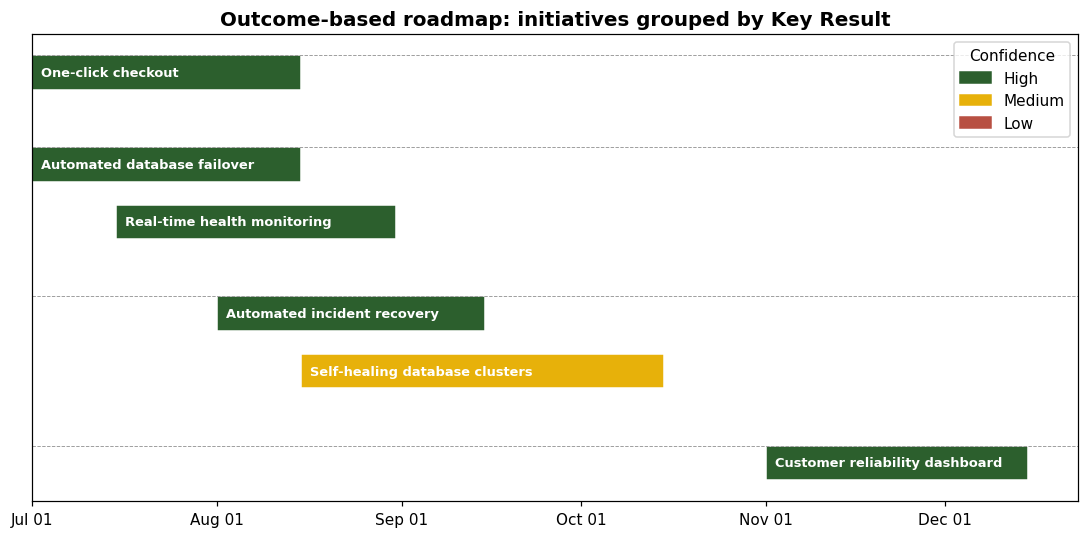

In [9]:
conf_color = {"High": "#2C5F2D", "Medium": "#E7B10A", "Low": "#B85042"}
krs = roadmap["key_result"].unique()
fig, ax = plt.subplots(figsize=(10, 5))

y = 0
yticks, yticklabels = [], []
for kr in krs:
    rows = roadmap[roadmap["key_result"] == kr]
    for _, r in rows.iterrows():
        ax.barh(y, r.duration_days, left=r.start, height=0.6,
                color=conf_color[r.confidence], edgecolor="white")
        ax.text(r.start, y, f"  {r.initiative}", va="center", ha="left",
                fontsize=8.5, color="white", fontweight="bold")
        yticks.append(y); yticklabels.append("")
        y += 1
    y += 0.6

ax.set_yticks([]); ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_title("Outcome-based roadmap: initiatives grouped by Key Result", fontsize=13, fontweight="bold")
handles = [plt.Rectangle((0,0),1,1, color=c) for c in conf_color.values()]
ax.legend(handles, conf_color.keys(), title="Confidence", loc="upper right")

# annotate KR group boundaries
running = 0
for kr in krs:
    n = len(roadmap[roadmap["key_result"] == kr])
    ax.axhline(running - 0.3, color="#999999", linewidth=0.6, linestyle="--")
    running += n + 0.6
plt.tight_layout()
plt.show()